In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

In [2]:
from sklearn.preprocessing import PolynomialFeatures,StandardScaler
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [3]:
df = pd.read_csv("manufacturing.csv")

In [4]:
df

,Temperature (°C),Pressure (kPa),Temperature x Pressure,Material Fusion Metric,Material Transformation Metric,Quality Rating
0,209.762701,8.050855,1688.769167,44522.217074,9.229576e+06,99.999971
1,243.037873,15.812068,3842.931469,63020.764997,1.435537e+07,99.985703
2,220.552675,7.843130,1729.823314,49125.950249,1.072839e+07,99.999758
3,208.976637,23.786089,4970.736918,57128.881547,9.125702e+06,99.999975
4,184.730960,15.797812,2918.345014,38068.201283,6.303792e+06,100.000000
...,...,...,...,...,...,...
3952,156.811578,21.794290,3417.596965,34941.963896,3.855501e+06,100.000000
3953,197.850406,8.291704,1640.516924,39714.857236,7.744742e+06,99.999997
3954,241.357144,16.391910,3956.304672,62657.690952,1.405957e+07,99.989318
3955,209.040239,23.809936,4977.234763,57195.985528,9.134036e+06,99.999975


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3957 entries, 0 to 3956
Data columns (total 6 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Temperature (°C)                3957 non-null   float64
 1   Pressure (kPa)                  3957 non-null   float64
 2   Temperature x Pressure          3957 non-null   float64
 3   Material Fusion Metric          3957 non-null   float64
 4   Material Transformation Metric  3957 non-null   float64
 5   Quality Rating                  3957 non-null   float64
dtypes: float64(6)
memory usage: 185.6 KB


In [6]:
df["Quality Rating"].min()

1.0

In [7]:
X = df[["Temperature x Pressure","Material Fusion Metric"]]
y =df["Quality Rating"]

In [8]:
scaler = StandardScaler()

In [9]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20,random_state=42)

In [10]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [11]:
regression = LinearRegression()

In [12]:
regression.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [13]:
y_pred = regression.predict(X_test)

In [14]:
print("R2 Score :",r2_score(y_test,y_pred))

R2 Score : 0.27639912516224385


In [18]:
r2_score_list =[]
for d in range(0,12):
    poly = PolynomialFeatures(degree=d)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)
    regression.fit(X_train_poly,y_train)
    y_pred_poly = regression.predict(X_test_poly)
    r2_score_list.append(r2_score(y_test,y_pred_poly))
print(f"r2 score list = {r2_score_list} a")

r2 score list = [-0.0009905958440958873, 0.27639912516224385, 0.5823227860075014, 0.7952131646010046, 0.915220012338847, 0.9717280876140969, 0.9928125897477933, 0.9985816797149109, 0.9997659037858657, 0.9999672719154346, 0.9999965426538928, 0.9999997287392062] a


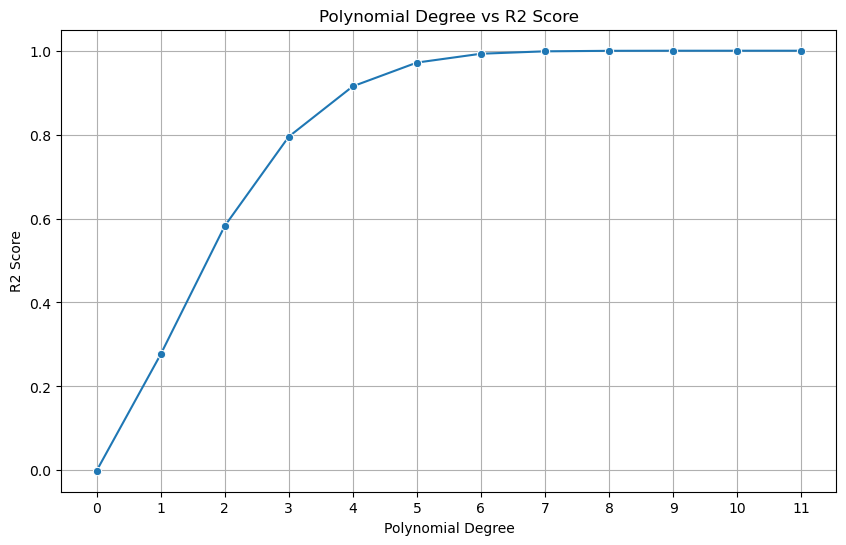

In [20]:
degrees = list(range(0, 12))

plt.figure(figsize=(10, 6))

sns.lineplot(
    x=degrees,
    y=r2_score_list,
    marker="o"
)

plt.xlabel("Polynomial Degree")
plt.ylabel("R2 Score")
plt.title("Polynomial Degree vs R2 Score")
plt.xticks(degrees)
plt.grid(True)
plt.show()